In [3]:
import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from tqdm.notebook import tqdm, trange
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# 🧠 Tropical Neural Network for California Housing Price Regression

## 📘 Project Overview

This notebook explores the application of **tropical algebra** within a custom neural network to predict **housing prices** using the **California Housing dataset**.

While traditional neural networks rely on standard linear algebra operations followed by common activation functions (like ReLU, tanh, or sigmoid), this project introduces a novel approach where:

- The **pre-activation transformation** (i.e., the operation before applying an activation function) is based on **tropical algebra**, specifically using the **max-plus semiring**.
- The **training process**, however, still leverages standard optimization techniques (e.g., **backpropagation**, **stochastic gradient descent**, **MSE loss**), allowing integration into PyTorch's automatic differentiation framework.

## 🌴 What Is Tropical Algebra?

Tropical algebra is a mathematical structure where:

- **Addition** becomes `max(a, b)`
- **Multiplication** becomes `a + b`

This algebraic framework has unique properties that make it useful in:
- Discrete optimization
- Scheduling problems
- Control theory
- Tropical geometry
- Linearity in tropical domain

In our context, we reinterpret dense layers using tropical linear operations to model the network's transformations.

## 🎯 Objective

The goal is to assess whether tropical transformations can serve as a useful **nonlinear mechanism** in regression models, specifically to:

- Replace the traditional affine transformation in neural layers with tropical algebra
- Retain gradient-based optimization to fit the model to real-world data
- Benchmark the performance against standard architectures (in future work)
- Validate properties of the tropical neural network using the tropical simplex (in future work)

## 🏗️ Implementation Plan

1. **Load and preprocess** the California Housing dataset.
2. **Define a custom neural layer** that implements tropical operations (e.g., tropical matrix-vector product).
3. **Stack tropical layers** into a feed-forward architecture.
4. **Train the model** using MSE loss and Adam optimizer.
5. **Evaluate performance** on validation and test sets.


## 1. Data Loading and Preprocessing

In [4]:
# MNIST Dataset download and load

torch.manual_seed(42)

train_transforms = transforms.Compose([
    transforms.Resize((28, 28)),    
    transforms.ToTensor()
])

eval_transforms = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=train_transforms)
valid_dataset = datasets.MNIST(root='data', train=True, download=True, transform=eval_transforms)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=eval_transforms)

train_mask = (train_dataset.targets == 0) | (train_dataset.targets == 1)
test_mask = (test_dataset.targets == 0) | (test_dataset.targets == 1)

train_dataset.data = train_dataset.data[train_mask]
train_dataset.targets = train_dataset.targets[train_mask]
valid_dataset.data = valid_dataset.data[train_mask]
valid_dataset.targets = valid_dataset.targets[train_mask]
test_dataset.data = test_dataset.data[test_mask]
test_dataset.targets = test_dataset.targets[test_mask]

val_frac = 0.3
val_size = int(val_frac * len(train_dataset))
train_size = len(train_dataset) - val_size

split_perm = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(42))
val_indices = split_perm[:val_size]
train_indices = split_perm[val_size:]

train_subset = torch.utils.data.Subset(train_dataset, train_indices.tolist())
valid_subset = torch.utils.data.Subset(valid_dataset, val_indices.tolist())

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"MNIST train samples: {len(train_loader.dataset)}")
print(f"MNIST valid samples: {len(valid_loader.dataset)}")
print(f"MNIST test samples:  {len(test_loader.dataset)}")

MNIST train samples: 8866
MNIST valid samples: 3799
MNIST test samples:  2115


## 2. Tropical MLP Implementation

In [ ]:
class TropLayer(nn.Module):
    """
    Tropical max-plus affine layer.
    Computes y_i = max_j (W_ij + x_j) with tropical bias via max(z, b).
    Bias is trainable and softly bounded with tanh scaling to avoid extremes.
    """
    
    def __init__(self, in_features: int, out_features: int, b_scale: float = 10.0):
        super().__init__()

        # Initialize weights with small random values to prevent large initial outputs
        self.W = nn.Parameter(torch.randn(out_features, in_features) * 0.1)

        # Initialize raw bias parameters to small negative values to start with low bias
        self.raw_b = nn.Parameter(torch.full((out_features,), -1.0))

        # Register b_scale as a buffer since it's a fixed hyperparameter, not learnable
        self.register_buffer("b_scale", torch.tensor(b_scale))

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Compute the max-plus affine transformation: z_ij = W_ij + x_j
        z_all = self.W.unsqueeze(0) + x.unsqueeze(1)

        # Take the max over the input dimension to get z_i = max_j (W_ij + x_j)
        z_trop = torch.max(z_all, dim=2).values

        # Compute the bias term with tanh scaling to keep it in a reasonable range
        b = torch.tanh(self.raw_b) * self.b_scale

        # Combine the tropical output with the bias using max(z, b)
        return torch.max(z_trop, b.unsqueeze(0))


class TropMLP(nn.Module):
    """
    Tropical MLP built from TropLayer blocks.
    """

    def __init__(self, input_size: int, output_size: int, hidden_size: int = 128, num_layers: int = 1, b_scale: float = 10.0):
        super().__init__()

        self.flatten = nn.Flatten()
        self.first_hidden = TropLayer(input_size, hidden_size, b_scale=b_scale)
        self.hidden_layers = nn.ModuleList([
            TropLayer(hidden_size, hidden_size, b_scale=b_scale) for _ in range(num_layers - 1)
        ])
        self.outputlay = TropLayer(hidden_size, output_size, b_scale=b_scale)

    def forward(self, x):
        x = self.flatten(x)
        x = self.first_hidden(x)
        for layer in self.hidden_layers:
            x = layer(x)
        x = self.outputlay(x)
        return x

## 3. Definition of Training, Validation, and Testing Modules

### 3.1 Training

In [6]:
def calculate_accuracy(y_pred, y):
    probs = torch.sigmoid(y_pred)
    preds = (probs >= 0.5).long()
    correct = preds.eq(y.long()).sum()
    acc = correct.float() / y.shape[0]
    return acc

In [7]:
def train(model, iterator, optimizer, criterion, log_first_batches: int = 0):
    """
    Trains the model for one epoch using the provided data iterator.

    Args:
        model: the neural network model (e.g., TropMLP)
        iterator: DataLoader that yields batches of (x, y) for training
        optimizer: optimization algorithm (e.g., Adam)
        criterion: loss function (e.g., nn.MSELoss or nn.BCEWithLogitsLoss)
        log_first_batches: if >0, log mean prob on first N batches (debug)

    Returns:
        train_loss: weighted average loss over all training examples
        train_acc: average accuracy over all batches
    """

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for batch_idx, (x, y) in enumerate(tqdm(iterator, desc="Training", leave=False)):
        if y.dim() == 1:
            y = y.unsqueeze(1)
        y = y.to(dtype=x.dtype)

        optimizer.zero_grad()

        y_pred = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        if log_first_batches > 0 and batch_idx < log_first_batches:
            probs = torch.sigmoid(y_pred)
            print(f"[train dbg] batch {batch_idx} prob mean={probs.mean().item():.3f} std={probs.std().item():.3f}")

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


### 3.2 Validation

In [8]:
def validate(model, iterator, criterion):
    """
    Evaluates the model on a validation set and returns the average loss.

    Args:
        model: PyTorch model to evaluate
        iterator: DataLoader for the validation data
        mse_loss_fn: loss function (nn.MSELoss or nn.BCEWithLogitsLoss)

    Returns:
        avg_loss: loss averaged over all validation examples
    """
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():

        for (x, y) in tqdm(iterator, desc="Evaluating", leave=False):
            
            if y.dim() == 1:
                y = y.unsqueeze(1)
            y = y.to(dtype=x.dtype)

            y_pred = model(x)

            loss = criterion(y_pred, y)

            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


## 4. Setup and Configuration

In [9]:
def epoch_time(start_time, end_time):
    """
    Calculates elapsed time between start and end timestamps.

    Args:
        start_time: float, start time in seconds
        end_time: float, end time in seconds

    Returns:
        elapsed_mins: integer number of minutes
        elapsed_secs: remaining seconds (after minutes are accounted for)
    """
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time // 60)
    elapsed_secs = int(elapsed_time % 60)
    return elapsed_mins, elapsed_secs

In [10]:
model = TropMLP(
    input_size=784,     
    output_size=1,     
    hidden_size=32,
    num_layers=2,       
    b_scale=3
)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-4)

## 5. Training and Validation Loop

In [11]:
EPOCHS = 150

best_valid_loss = float('inf')

results = []

for epoch in trange(EPOCHS, desc="Epochs"):

    start_time = time.monotonic()

    # Logga le prime 2 batch per vedere la distribuzione delle probabilità
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, log_first_batches=0)
    valid_loss, valid_acc = validate(model, valid_loader, criterion)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'tropical_model.pt')
    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    results.append({
        "Train Loss": train_loss,
        "Train Acc": train_acc,
        "Valid Loss": valid_loss,
        "Valid Acc": valid_acc})

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')


Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

Training:   0%|          | 0/139 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 1s
	Train Loss: 0.927 | Train Acc: 53.15%
	 Val. Loss: 0.904 |  Val. Acc: 53.41%


Training:   0%|          | 0/139 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 149 | Epoch Time: 0m 1s
	Train Loss: 0.483 | Train Acc: 98.66%
	 Val. Loss: 0.483 |  Val. Acc: 98.67%


Training:   0%|          | 0/139 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch: 150 | Epoch Time: 0m 1s
	Train Loss: 0.483 | Train Acc: 98.65%
	 Val. Loss: 0.483 |  Val. Acc: 98.67%


## 6. Results

### 6.1 Training and Validation Loss Curves

In [1]:
def plot_results(results):

    plt.figure(figsize=(12, 5))
    plt.plot(results.index, results['Train Loss'], label='Train Loss', marker='o')
    plt.plot(results.index, results['Valid Loss'], label='Valid Loss', marker='s')
    plt.title('Training and Validation Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.xticks(results.index)
    plt.xticks(rotation=90)
    plt.grid(True)


    plt.figure(figsize=(12, 5))
    plt.plot(results.index, results['Train Acc'], label='Train Acc', marker='o')
    plt.plot(results.index, results['Valid Acc'], label='Valid Acc', marker='s')
    plt.title('Training and Validation Accuracy', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.legend(fontsize=12)
    plt.xticks(results.index)
    plt.xticks(rotation=90)
    plt.grid(True)


    plt.tight_layout()
    plt.show()

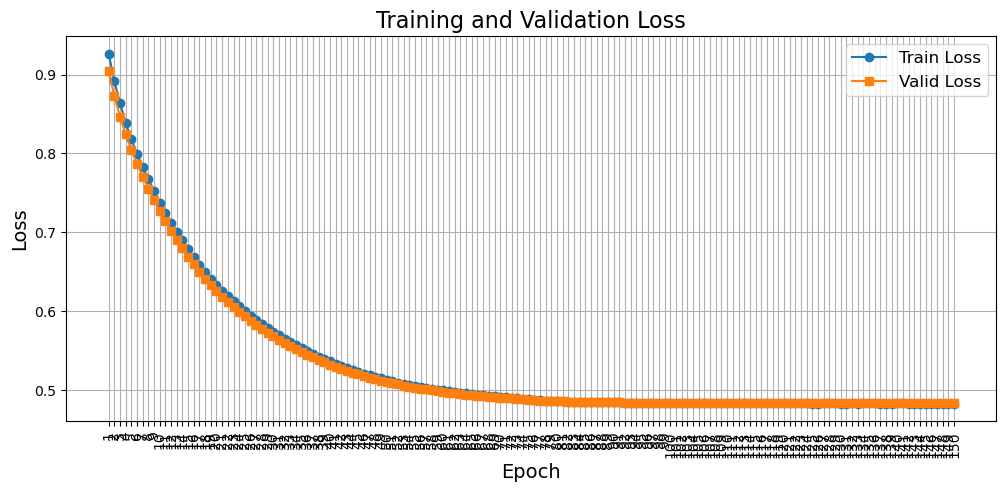

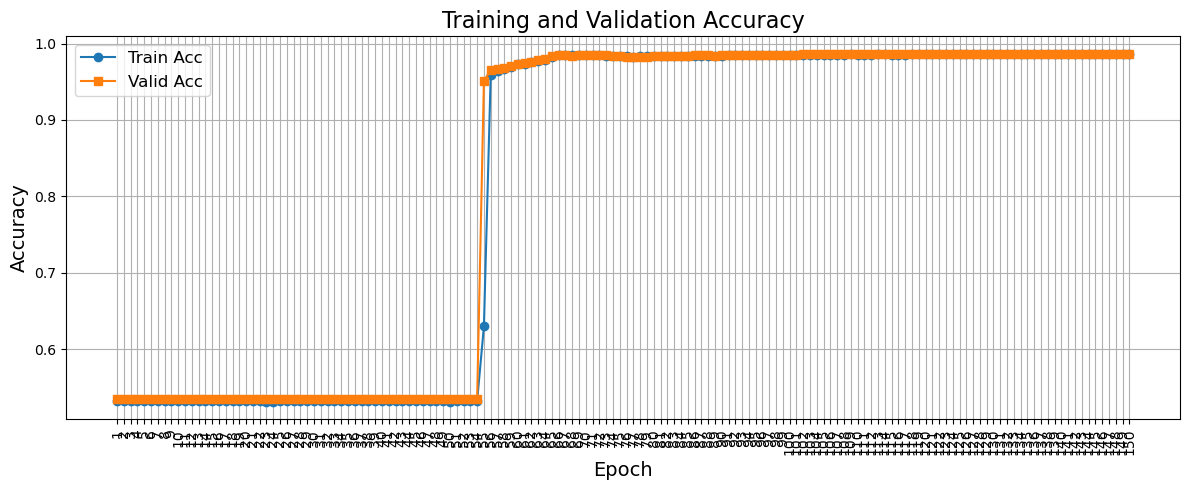

In [12]:
df_results = pd.DataFrame(results, index=range(1, EPOCHS+1))
plot_results(df_results)

### Test Results

In [13]:
model.load_state_dict(torch.load('tropical_model.pt'))

model.eval()
test_loss, test_acc = validate(model, test_loader, criterion)
print(f'Test Loss: {test_loss:.3f}')
print(f'Test Accuracy: {test_acc*100:.2f}%')

C:\Users\aless\AppData\Local\Temp\ipykernel_29324\300765337.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('tropical_model.pt'))


Evaluating:   0%|          | 0/34 [00:00<?, ?it/s]

Test Loss: 0.484
Test Accuracy: 98.33%


Image selected: 1


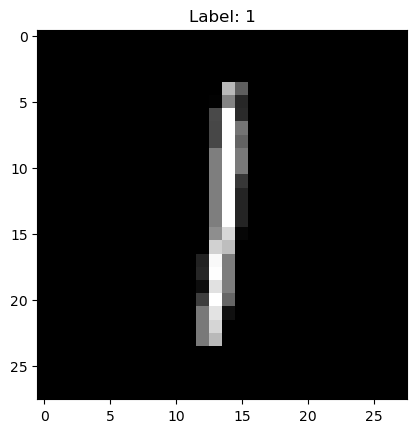


Number of pixels: 784
Pixel values (first 20): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

--- Generating constraints for LP ---
x_0 >= bias0 + 0.000000;
x_0 <= bias0 + 0.013000;
x_1 >= bias0 + 0.000000;
x_1 <= bias0 + 0.013000;
x_2 >= bias0 + 0.000000;
x_2 <= bias0 + 0.013000;
x_3 >= bias0 + 0.000000;
x_3 <= bias0 + 0.013000;
x_4 >= bias0 + 0.000000;
x_4 <= bias0 + 0.013000;
x_5 >= bias0 + 0.000000;
x_5 <= bias0 + 0.013000;
x_6 >= bias0 + 0.000000;
x_6 <= bias0 + 0.013000;
x_7 >= bias0 + 0.000000;
x_7 <= bias0 + 0.013000;
x_8 >= bias0 + 0.000000;
x_8 <= bias0 + 0.013000;
x_9 >= bias0 + 0.000000;
x_9 <= bias0 + 0.013000;
x_10 >= bias0 + 0.000000;
x_10 <= bias0 + 0.013000;
x_11 >= bias0 + 0.000000;
x_11 <= bias0 + 0.013000;
x_12 >= bias0 + 0.000000;
x_12 <= bias0 + 0.013000;
x_13 >= bias0 + 0.000000;
x_13 <= bias0 + 0.013000;
x_14 >= bias0 + 0.000000;
x_14 <= bias0 + 0.013000;
x_15 >= bias0 + 0.000000;
x_15 <= bias0 + 0.013000;
x_16 >= bias0 + 0.000000;
x_16 <= bias0

In [14]:
# Generate LP constraints for a specific test image
dataiter = iter(test_loader) 
images, labels = next(dataiter)

idx = 34
img_tensor = images[idx] 
label = labels[idx].item()

print(f"Image selected: {label}")

plt.imshow(img_tensor.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

pixel_values = img_tensor.flatten().numpy()

print(f"\nNumber of pixels: {len(pixel_values)}")
print("Pixel values (first 20):", pixel_values[:20])

epsilon = 0.013
print("\n--- Generating constraints for LP ---")
for i, p in enumerate(pixel_values):

    lb = max(0.0, p - epsilon)
    ub = min(1.0, p + epsilon)
    
    print(f"x_{i} >= bias0 + {lb:.6f};")
    print(f"x_{i} <= bias0 + {ub:.6f};")

In [50]:
# Nel notebook:
with torch.no_grad():
    out = model(img_tensor.unsqueeze(0))
    print(f"Output reale della rete: {torch.sigmoid(out).item()}")

Output reale della rete: 0.611280620098114


Raccolte 16 immagini misclassificate


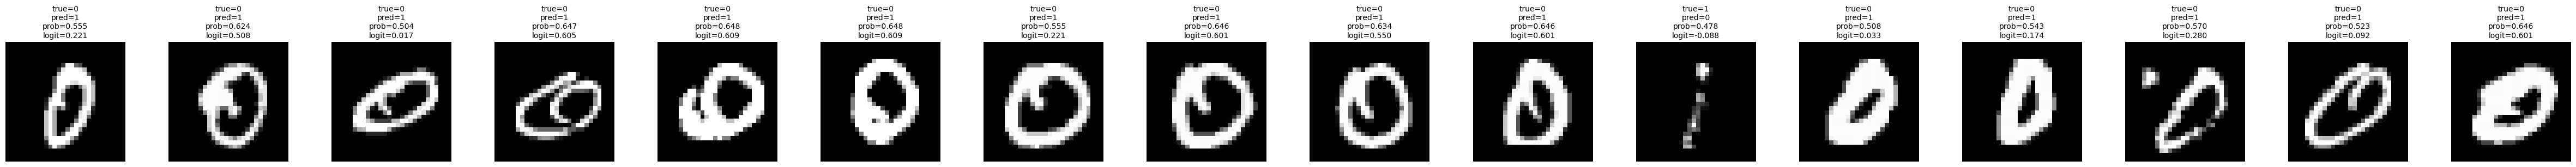

In [33]:
# Trova e mostra alcune immagini misclassificate con probabilità e logit
misclassified = []
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x)
        probs = torch.sigmoid(logits).squeeze(1)
        preds = (probs >= 0.5).long()
        mism = preds != y
        if mism.any():
            for img, true_lbl, pred_lbl, prob, logit in zip(
                x[mism], y[mism], preds[mism], probs[mism], logits.squeeze(1)[mism]
            ):
                misclassified.append(
                    {
                        "img": img.cpu(),
                        "true": int(true_lbl.item()),
                        "pred": int(pred_lbl.item()),
                        "prob": float(prob.item()),
                        "logit": float(logit.item()),
                    }
                )
                if len(misclassified) >= 20:
                    break
        if len(misclassified) >= 20:
            break

print(f"Raccolte {len(misclassified)} immagini misclassificate")

# Visualizza le prime n immagini misclassificate
n_show = min(20, len(misclassified))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for ax, sample in zip(axes, misclassified[:n_show]):
    ax.imshow(sample["img"].squeeze().numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"true={sample['true']}\npred={sample['pred']}\nprob={sample['prob']:.3f}\nlogit={sample['logit']:.3f}",
        fontsize=10,
    )
plt.tight_layout()
plt.show()

In [37]:
from PIL import Image, ImageOps # ImageOps serve per l'inversione

# Usa le stesse trasformazioni, ma gestiamo l'inversione manualmente
inference_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor()
])

def predict_single_image(image_path, model, device='cpu'):
    # 1. Carica l'immagine
    image = Image.open(image_path).convert('L') # Converti subito in scala di grigi
    
    # 2. Inverti i colori se necessario (assumiamo sfondo bianco/cifra nera)
    # Se la tua immagine è già bianca su nero, commenta questa riga
    image = ImageOps.invert(image) 
    
    # 3. Visualizza cosa vede la rete (Debug)
    # Ridimensioniamo prima del tensore per vedere l'effetto pixel
    debug_img = image.resize((28, 28))
    print("--- Anteprima dei valori dei pixel (28x28) ---")
    # Stampiamo i valori grezzi approssimati
    for y in range(28):
        row = ""
        for x in range(28):
            val = debug_img.getpixel((x, y))

            row += f"{val:3d} " 
        print(row)
    print("--------------------------------------------")

    # 4. Applica le trasformazioni per il modello
    image_tensor = inference_transform(image)
    
    # Aggiungi dimensione batch: [1, 1, 28, 28]
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        logit = model(image_tensor)
        prob = torch.sigmoid(logit).squeeze().item()
        pred = 1 if prob >= 0.5 else 0
        
    return pred, prob

In [38]:

# --- Esempio di utilizzo (Assumendo che 'model' sia già caricato) ---

# Se vuoi testare con una immagine presa dal tuo test set per verifica rapida:
print("--- Test from Dataset ---")
idx = 0 # Cambia questo indice per provare altri numeri
test_img_tensor, true_label = test_dataset[idx] 

print(test_img_tensor)
print(f"Testing on dataset image with true label: {true_label}")



--- Test from Dataset ---
tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.000

In [41]:
pred, prob = predict_single_image("C:\\Users\\aless\\Downloads\\0.jpg", model)
print(f"Predicted: {pred} (Probability of be a one: {prob:.4f})")

--- Anteprima dei valori dei pixel (28x28) ---
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0   0   0  33  68  86  81  52  11   0   0   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   0   0  65 179 242 255 255 255 255 213 112   8   0   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0   1 123 249 255 251 154  93 115 217 255 255 181  21   0   0   0   0   0   0   0   0 
  0   0   0   0   0   0   0 113 255 255 254 102   0   0   0  27 211 255 255 183   9   0   0   0   0   0   0   0 
  0   0   0   0   0   0  47 244 255 255 184   0   0   0   0   0  77 252 255 255 120   0   0   0   0   0   0   0 
  0   0   0   0   0   0 166 255 255 255  85   0   0   0   0   0   6 210 255 255 233  27   0   0   0   0   0   0 
  0   0   0   0   0  36 244 255 255 239  27   0  